# Heat Transfer Optimization: Symmetric Circular Holes in Periodic Slabs

Maximize the spectral heat transfer between two identical patterned slabs by optimizing the hole diameter.

```
  [vac]  |  slab (holes)  |  gap d  |  slab (holes)  |  [vac]
```

In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

jax.config.update("jax_enable_x64", True)

from fmmax.fmm import Formulation
from fluxmax.optimization.design_tools import circular_exclusion_permittivity
from fluxmax.parallelism import compute_bz_average, flatten_k_points
from fluxmax.physics import heat_transfer as ht
from fluxmax.setup import two_body as ss

print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0)]


## Parameters

In [ ]:
# Physical parameters in fmmax natural units: c = hbar = kB = 1
WAVELENGTH = 1.0
PITCH = 1.0
SLAB_THICKNESS = 0.5
GAP = 0.2
EPS_SLAB = 2.25 + 0.5j
EPS_HOLE = 1.0 + 0.0j
SOFTNESS = 0.01  # Helps optimization to have a nonzero gradient at surface

APPROXIMATE_NUM_TERMS = 25
BZ_GRID = (5, 5)
K_CHUNK_SIZE = 5
RESOLUTION = PITCH / 512
SOFT_EDGE_SHARPNESS = 180.0

plv, expansion, in_plane_wavevector = ss.make_rcwa_setup(
    pitch=PITCH,
    approximate_num_terms=APPROXIMATE_NUM_TERMS,
    brillouin_grid_shape=BZ_GRID,
)
k_points = flatten_k_points(in_plane_wavevector)
N_BZ = int(k_points.shape[0])
AREA = ss.cell_area(plv)
OMEGA = float(ht.wavelength_to_omega(jnp.asarray(WAVELENGTH)))

print(f"Actual number of Fourier terms: {expansion.num_terms}")
print(f"Flattened BZ points: {N_BZ}")
print(f"k_chunk_size: {K_CHUNK_SIZE}")
print(f"Unit-cell area: {float(AREA):.4f}")
print(f"omega: {OMEGA:.4f}")
print(f"EPS_SLAB = {EPS_SLAB}, EPS_HOLE = {EPS_HOLE}")

Actual number of Fourier terms: 21
Flattened BZ points: 25
k_chunk_size: 5
Unit-cell area: 1.0000
omega: 6.2832
EPS_SLAB = (2.25+0.5j), EPS_HOLE = (1+0j)


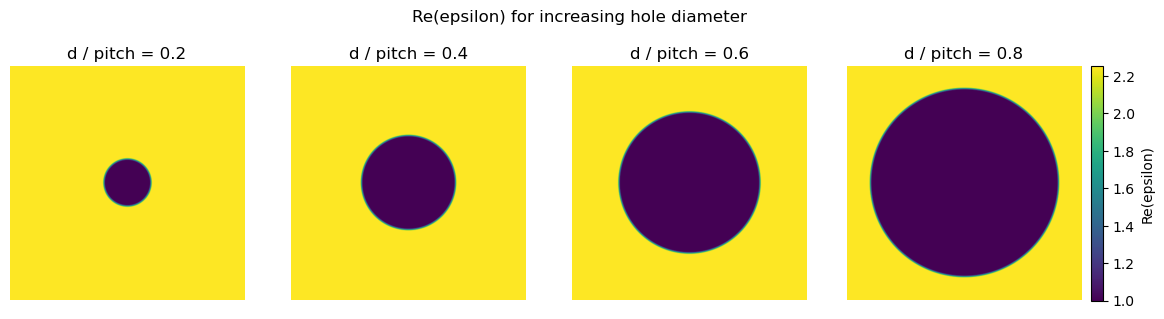

In [ ]:
diameters_to_show = [0.2, 0.4, 0.6, 0.8]
fig, axes = plt.subplots(1, len(diameters_to_show), figsize=(12, 3))
for ax, diameter in zip(axes, diameters_to_show):
    eps_grid = circular_exclusion_permittivity(
        pitch=PITCH,
        diameter=diameter,
        eps_slab=EPS_SLAB,
        eps_exclusion=EPS_HOLE,
        resolution=RESOLUTION,
        softness=SOFTNESS,
    )
    im = ax.imshow(
        np.real(np.asarray(eps_grid)),
        origin="lower",
        cmap="viridis",
        vmin=float(np.real(EPS_HOLE)),
        vmax=float(np.real(EPS_SLAB)),
    )
    ax.set_title(f"d / pitch = {diameter:.1f}")
    ax.axis("off")
fig.suptitle("Re(epsilon) for increasing hole diameter", y=1.02)
plt.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04, label="Re(epsilon)")
plt.tight_layout()
plt.show()

## Single-k kernel and chunked BZ objective

`compute_bz_average` expects a kernel of the form `kernel(omega_i, eps_i, k_points_chunk) -> (n_k_chunk,)`. The physics below is written first for a **single** `k` and then vectorized over the current chunk supplied by the dispatcher.

In [ ]:
def symmetric_transfer_single_k(
    omega: jnp.ndarray,
    permittivity_array: jnp.ndarray,
    k_point: jnp.ndarray,
) -> jnp.ndarray:
    wavelength = 2.0 * jnp.pi / omega
    thickness = jnp.asarray(SLAB_THICKNESS)
    gap_distance = jnp.asarray(GAP)

    eigensolve_kw = dict(
        wavelength=wavelength,
        in_plane_wavevector=k_point,
        primitive_lattice_vectors=plv,
        expansion=expansion,
    )

    vac_lsr = ss.eigensolve_uniform(**eigensolve_kw, permittivity=1.0 + 0.0j)
    slab_lsr = ss.eigensolve_patterned(
        **eigensolve_kw,
        permittivity_array=permittivity_array,
    )

    R_A, T_A, _ = ss.body_s_matrices(vac_lsr, slab_lsr, thickness, is_body_A=True)
    R_B, T_B, _ = ss.body_s_matrices(vac_lsr, slab_lsr, thickness, is_body_A=False)

    F_re, F_ah, F = ht.poynting_flux_matrices(vac_lsr)
    sigma_A = ht.compute_sigma(R_A, T_A, F_re, F_ah)
    sigma_B = ht.compute_sigma(R_B, T_B, F_re, F_ah)
    P = ht.propagation_matrix(vac_lsr.eigenvalues, gap_distance)
    tau = ht.spectral_transfer(sigma_A, sigma_B, P, R_A, R_B, F)
    return jnp.real(tau)


def symmetric_bz_kernel(
    omega_i: jnp.ndarray,
    eps_i: jnp.ndarray,
    k_points_chunk: jnp.ndarray,
) -> jnp.ndarray:
    return jax.vmap(lambda k_point: symmetric_transfer_single_k(omega_i, eps_i, k_point))(k_points_chunk)


def transfer_from_diameter(diameter: jnp.ndarray) -> jnp.ndarray:
    eps_grid = circular_exclusion_permittivity(
        pitch=PITCH,
        diameter=diameter,
        eps_slab=EPS_SLAB,
        eps_exclusion=EPS_HOLE,
        resolution=RESOLUTION,
        softness=0.01,
    )
    tau_avg = compute_bz_average(
        symmetric_bz_kernel,
        omega_1d=jnp.asarray([OMEGA]),
        eps_omega=eps_grid[jnp.newaxis, ...],
        k_points=k_points,
        execution_mode="single_device_chunked",
        k_chunk_size=K_CHUNK_SIZE,
        omega_chunk_size=1,
    )
    return tau_avg[0] / AREA


d_test = jnp.asarray(0.4)
tau_test = transfer_from_diameter(d_test)
print(f"{float(tau_test):.6e}")

5.203868e+00


## Gradient check

The default `JONES_FOURIER` formulation uses `jax.lax.stop_gradient` on
the tangent vector field. This means `jax.grad` computes the **partial**
derivative (holding the vector field fixed), while finite differences compute
the **total** derivative (recomputing the vector field at each point).
The two disagree because they measure different mathematical quantities.

To validate that `jax.grad` is correct, we switch to `Formulation.FFT` (which
has no vector field) so that both AD and FD compute the same thing.

In [ ]:
# Use FFT formulation for the gradient check so that AD and FD agree.
def _transfer_single_k_fft(omega, permittivity_array, k_point):
    wavelength = 2.0 * jnp.pi / omega
    thickness = jnp.asarray(SLAB_THICKNESS)
    gap_distance = jnp.asarray(GAP)
    eigensolve_kw = dict(
        wavelength=wavelength,
        in_plane_wavevector=k_point,
        primitive_lattice_vectors=plv,
        expansion=expansion,
    )
    vac_lsr = ss.eigensolve_uniform(**eigensolve_kw, permittivity=1.0 + 0.0j)
    slab_lsr = ss.eigensolve_patterned(
        **eigensolve_kw,
        permittivity_array=permittivity_array,
        formulation=Formulation.FFT,
    )
    R_A, T_A, _ = ss.body_s_matrices(vac_lsr, slab_lsr, thickness, is_body_A=True)
    R_B, T_B, _ = ss.body_s_matrices(vac_lsr, slab_lsr, thickness, is_body_A=False)
    F_re, F_ah, F = ht.poynting_flux_matrices(vac_lsr)
    sigma_A = ht.compute_sigma(R_A, T_A, F_re, F_ah)
    sigma_B = ht.compute_sigma(R_B, T_B, F_re, F_ah)
    P = ht.propagation_matrix(vac_lsr.eigenvalues, gap_distance)
    tau = ht.spectral_transfer(sigma_A, sigma_B, P, R_A, R_B, F)
    return jnp.real(tau)


def _bz_kernel_fft(omega_i, eps_i, k_points_chunk):
    return jax.vmap(lambda k: _transfer_single_k_fft(omega_i, eps_i, k))(k_points_chunk)


def _transfer_fft(diameter):
    eps_grid = circular_exclusion_permittivity(
        pitch=PITCH, diameter=diameter, eps_slab=EPS_SLAB,
        eps_exclusion=EPS_HOLE, resolution=RESOLUTION, softness=0.01,
    )
    tau_avg = compute_bz_average(
        _bz_kernel_fft, omega_1d=jnp.asarray([OMEGA]),
        eps_omega=eps_grid[jnp.newaxis, ...], k_points=k_points,
        execution_mode="single_device_chunked",
        k_chunk_size=K_CHUNK_SIZE, omega_chunk_size=1,
    )
    return tau_avg[0] / AREA


grad_val = jax.grad(_transfer_fft)(d_test)
eps_fd = 1e-5
fd_grad = (_transfer_fft(d_test + eps_fd) - _transfer_fft(d_test - eps_fd)) / (2 * eps_fd)

print(f"d(tau / area) / d(diameter): {float(grad_val):.6e}")
print(f"finite-difference check: {float(fd_grad):.6e}")
if abs(float(fd_grad)) > 0:
    rel_err = abs(float(grad_val) - float(fd_grad)) / abs(float(fd_grad))
    print(f"relative error: {rel_err:.2e}")

d(tau / area) / d(diameter): -3.176829e-02
finite-difference check: -3.175399e-02
relative error: 4.50e-04


## Optimization with optax

We parameterize the diameter as

$$d = 	\text{pitch} \cdot \sigma(t), \qquad \sigma(t) = \frac{1}{1 + e^{-t}}$$

so that $d \in (0, \text{pitch})$ for any unconstrained $t \in \mathbb{R}$. We maximize transfer by minimizing its negative.

In [ ]:
def diameter_from_param(t: jnp.ndarray) -> jnp.ndarray:
    return PITCH * jax.nn.sigmoid(t)


def loss(t: jnp.ndarray) -> jnp.ndarray:
    return -transfer_from_diameter(diameter_from_param(t))


loss_and_grad = jax.jit(jax.value_and_grad(loss))

LEARNING_RATE = 0.1
N_STEPS = 40
D_INIT = 0.3
t = jnp.asarray(float(np.log(D_INIT / (PITCH - D_INIT))))
optimizer = optax.adam(LEARNING_RATE)
opt_state = optimizer.init(t)

history = {"step": [], "diameter": [], "transfer": [], "loss": []}

print(f"{'Step':>5}  {'diameter':>10}  {'tau / area':>14}")
print("-" * 54)
for step in range(N_STEPS):
    loss_value, grads = loss_and_grad(t)
    updates, opt_state = optimizer.update(grads, opt_state)
    t = optax.apply_updates(t, updates)

    diameter = float(diameter_from_param(t))
    transfer = float(-loss_value)
    loss_scalar = float(loss_value)

    history["step"].append(step)
    history["diameter"].append(diameter)
    history["transfer"].append(transfer)
    history["loss"].append(loss_scalar)

    if step % 5 == 0 or step == N_STEPS - 1:
        print(f"{step:>5}  {diameter:>10.4f}  {transfer:>14.6e}")

print(f"\nOptimal diameter: {history['diameter'][-1]:.4f}  (in units of pitch)")
print(f"Max transfer / area: {history['transfer'][-1]:.6e}")

 Step    diameter      tau / area
------------------------------------------------------
    0      0.3214    5.195330e+00
    5      0.4228    5.203694e+00
   10      0.3923    5.203856e+00
   15      0.3693    5.202468e+00
   20      0.3925    5.203455e+00
   25      0.4048    5.203804e+00
   30      0.3868    5.203581e+00
   35      0.3863    5.203514e+00
   39      0.3966    5.203820e+00

Optimal diameter: 0.3966  (in units of pitch)
Max transfer / area: 5.203820e+00


## Results

Only the optimization history is plotted here. The transfer-versus-diameter sweep overlay from the older notebook is intentionally omitted.

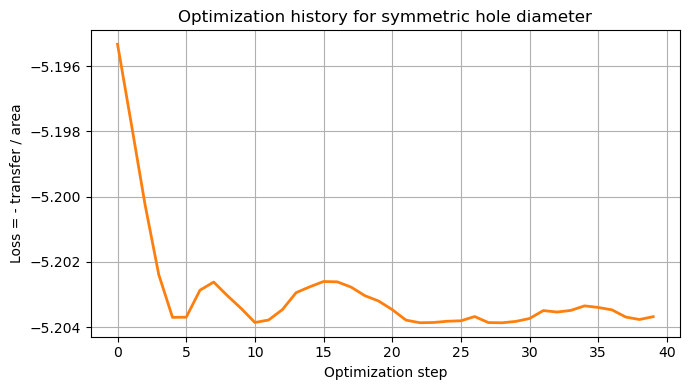

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history["step"], history["loss"], color="C1", linewidth=2)
plt.xlabel("Optimization step")
plt.ylabel("Loss = - transfer / area")
plt.title("Optimization history for symmetric hole diameter")
plt.grid(True)
plt.tight_layout()
plt.show()

## Optimal permittivity pattern

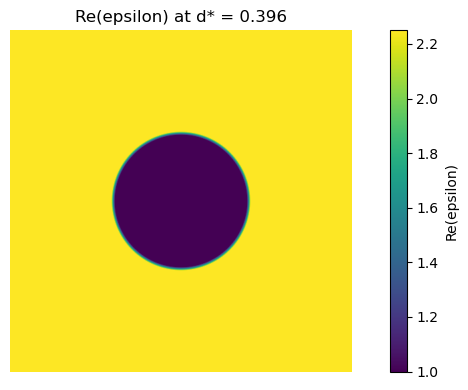

In [ ]:
d_opt = history["diameter"][-1]
eps_opt = circular_exclusion_permittivity(
    pitch=PITCH,
    diameter=jnp.asarray(d_opt),
    eps_slab=EPS_SLAB,
    eps_exclusion=EPS_HOLE,
    resolution=RESOLUTION,
    softness=0.01,
)

fig, axes = plt.subplots(1, 1, figsize=(8, 4))
for ax, part, label in zip([axes], [np.real], ["Re(epsilon)"]):
    arr = part(np.asarray(eps_opt))
    im = ax.imshow(arr, origin="lower", cmap="viridis")
    plt.colorbar(im, ax=ax, label=label)
    ax.set_title(f"{label} at d* = {d_opt:.3f}")
    ax.axis("off")

plt.tight_layout()
plt.show()